# Hospital Readmission Analysis Project

## Project Overview

This project analyzes patient encounter data from 130 US hospitals between 1999 and 2008 to evaluate treatment effectiveness, hospital readmission risk factors, and demographic influences on recovery outcomes among diabetic patients.

The objective is to generate data-driven insights that can support healthcare providers in improving treatment strategies, reducing readmission rates, and optimizing patient care management.


## Dataset Information

**Source:** Kaggle – Diabetes 130-US Hospitals for years 1999–2008 Dataset  
**Number of Records:** ~70,000+ hospital encounters  
**Time Period:** 1999–2008  
**Hospitals Covered:** 130 US hospitals  

### Key Features:
- Age  
- Gender  
- Race  
- Time in hospital  
- Encounter ID  
- Treatment types (e.g., insulin, metformin, glipizide)  
- Readmission status  

## Data Definitions

This section explains the meaning of key categorical values used in the dataset to ensure proper interpretation of results.


### Readmission Status (`readmitted`)

This variable indicates whether a patient was readmitted after discharge.

- **`NO`** – The patient was not readmitted.
- **`>30`** – The patient was readmitted after more than 30 days.
- **`<30`** – The patient was readmitted within 30 days (classified as early readmission).

In this project:
- `<30` is defined as **early_readmission**.
- `NO` and `>30` are treated as **successful_recovery** outcomes.


### Medication Status Variables  
(Examples: `metformin`, `insulin`, `glipizide`, etc.)

These variables describe changes in medication dosage during the hospital encounter.

- **`Up`** – Dosage was increased.
- **`Down`** – Dosage was decreased.
- **`Steady`** – Dosage remained the same.
- **`No`** – Medication was not prescribed during the encounter.

These values are analyzed to evaluate treatment effectiveness and their relationship with early readmission risk.


### Hospital Stay (`time_in_hospital`)

Represents the number of days the patient stayed in the hospital during the encounter.

In this analysis, hospital stay was categorized as:
- **Short Stay:** 1–3 days
- **Medium Stay:** 4–7 days
- **Long Stay:** 8–14 days
- **Very Long Stay:** 15+ days


### Clinical Complexity Indicators

- **`number_diagnoses`** – Total number of diagnosed conditions.
- **`number_emergency`** – Number of emergency visits.
- **`num_procedures`** – Number of medical procedures performed.
- **`num_medications`** – Total medications administered during the encounter.

Higher values in these variables may indicate greater medical complexity and increased readmission risk.

**Note:** This dataset is cleaned and preprocessed in a separate ETL notebook.  
- Missing values (?) replaced with NaN.  
- Categorical variables are standardized.  
- Duplicates are removed.  
- Invalid or unknown `gender` values are filtered out to ensure accurate demographic analysis.  

The cleaned dataset is saved as a new CSV and used for all analysis in this notebook.



## Key Business Questions

1. Which treatments are most effective for different patient groups?
2. What factors influence hospital readmission rates?
3. How do demographic factors (age, gender, race) affect recovery outcomes?

## Analysis Approach

Analysis is structured around the three key business questions.  
We will perform exploratory data analysis (EDA), statistical aggregations, and visualizations to identify patterns and insights.

The main goals are:

- Determine which treatments reduce readmission rates for specific patient groups
- Identify factors contributing to readmission risk
- Explore demographic influences on recovery outcomes

## Loading Cleaned Data


In [1]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

# Load dataset
df = pd.read_csv("cleaned_diabetic_dataset.csv")  

# quick overview
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


We load the preprocessed dataset into the notebook. The CSV contains all cleaned and standardized fields, ready for exploratory and statistical analysis.
Displaying the first few records provides an overview of the data structure and feature values.

## Preprocessing Readmission & Treatment Flags

To facilitate analysis of treatment effectiveness and patient outcomes, we create binary flags based on the original `readmitted` column:

1. **Early Readmission (`early_readmission`)** – indicates if a patient was readmitted within 30 days.  
   - Encoded as `1` for `<30` days and `0` otherwise.

2. **Successful Recovery (`successful_recovery`)** – indicates if a patient was not readmitted or readmitted after 30 days.  
   - Encoded as `1` for `NO` or `>30` and `0` otherwise.

These flags simplify analysis by converting categorical readmission outcomes into binary variables, which are easier to use in statistical aggregations, statistical comparisons, group analysis, and visualizations.

In [2]:
# Early readmission flag (<30 days)
df['early_readmission'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Successful recovery = NO or >30
df['successful_recovery'] = df['readmitted'].apply(lambda x: 1 if x in ['NO', '>30'] else 0)

## Key Question 1 – Treatment Effectiveness for Different Patient Groups

### Categorizing Age Groups for Clearer Insight

The original dataset provides age in ranges (e.g., `[10-20), [20-30), [50-60) etc`).  
To improve interpretability and make subgroup analysis clearer, we consolidate age ranges into broader, meaningful categories:

- **Young (0–30)**
- **Middle (30–60)**
- **Senior (60–80)**
- **Elderly (80+)**

This grouping allows for clearer comparison of treatment effectiveness across major life stages and helps identify high-risk age segments.

In [3]:
# Categorize age groups function
def age_category(age_range):
    if age_range in ['[0-10)', '[10-20)', '[20-30)']:
        return 'Young (0-30)'
    elif age_range in ['[30-40)', '[40-50)', '[50-60)']:
        return 'Middle (30-60)'
    elif age_range in ['[60-70)', '[70-80)']:
        return 'Senior (60-80)'
    else:
        return 'Elderly (80+)'

df['age_group'] = df['age'].apply(age_category)


### Treatment Combination Effectiveness by Age Group

Objective:

To evaluate which treatment combinations (Metformin, Glipizide, Insulin) perform best within each age category.

Methodology:

- Group data by `age_group` and treatment combinations.
- Count total patients within each group.
- Sum early readmissions.
- Calculate early readmission rate (%).
- Filter groups with at least 30 patients to ensure reliability.
- Identify the **treatment combination with the lowest readmission rate per age group**.

By selecting the minimum readmission rate per age group (with adequate sample size), we highlight the most effective and statistically reliable treatment strategy for each age category.


In [4]:
# List of key diabetes medications
treatment_cols = [ 'metformin','glipizide','insulin' ]

In [6]:
# Aggregate treatments by age group
treatment_age = (
    df.groupby(['age_group'] + treatment_cols)
      .agg(
          total_patients=('encounter_id', 'count'),
          early_readmissions=('early_readmission', 'sum')
      )
      .assign(
          early_readmission_rate_percent=lambda x:
          (x['early_readmissions'] / x['total_patients'] * 100).round(2)
      )
      .reset_index()
)

# Filter treatments with at least 30 patients
filtered_age = treatment_age[treatment_age['total_patients'] >= 30]

# Select the treatment with the minimum early readmission rate per age group
min_readmission_by_age = (
    filtered_age.sort_values(['age_group', 'early_readmission_rate_percent'])
    .groupby('age_group')
    .head(1)
    .reset_index(drop=True)
)

# Sort the final result by logical age order
age_order = ['Young (0-30)', 'Middle (30-60)', 'Senior (60-80)', 'Elderly (80+)']
min_readmission_by_age['age_group'] = pd.Categorical(
    min_readmission_by_age['age_group'],
    categories=age_order,
    ordered=True
)
min_readmission_by_age = min_readmission_by_age.sort_values('age_group').reset_index(drop=True)

# Display the final result
min_readmission_by_age

,age_group,metformin,glipizide,insulin,total_patients,early_readmissions,early_readmission_rate_percent
0,Young (0-30),Steady,No,Steady,49,2,4.08
1,Middle (30-60),No,Up,Steady,34,1,2.94
2,Senior (60-80),Steady,Steady,Up,93,4,4.30
3,Elderly (80+),No,Steady,Up,80,5,6.25


### Treatment Combination Effectiveness by Gender

Objective:

To determine which treatment combinations are most effective for male and female patients separately.

Methodology:

- Group data by `gender` and treatment combinations.
- Count total patients within each group.
- Sum early readmissions.
- Calculate early readmission rate (%).
- Filter groups with at least 30 patients to ensure reliability.
- Identify the **treatment combination with the lowest readmission rate per gender**.

By selecting the minimum readmission rate per gender (with adequate sample size), we highlight the most effective and statistically reliable treatment strategy for each gender group.


In [7]:
# Aggregate treatments by gender
treatment_gender = (
    df.groupby(['gender'] + treatment_cols)
      .agg(
          total_patients=('encounter_id','count'),       # Count of patients per gender-treatment combo
          early_readmissions=('early_readmission','sum') # Sum of early readmissions
      )
      .assign(
          early_readmission_rate_percent=lambda x:
          (x['early_readmissions'] / x['total_patients'] * 100).round(2) # % readmission
      )
      .reset_index()
)

# Filter and select minimum readmission rate per gender
min_readmission_by_gender = (
    treatment_gender[treatment_gender['total_patients'] >= 30]           # Ensure sufficient sample size
    .sort_values(['gender', 'early_readmission_rate_percent'])           # Sort by gender then rate
    .groupby('gender')
    .head(1)                                                             # Pick treatment with lowest rate per gender
    .reset_index(drop=True)
)

# Display the final result
min_readmission_by_gender

,gender,metformin,glipizide,insulin,total_patients,early_readmissions,early_readmission_rate_percent
0,Female,No,Up,Steady,69,3,4.35
1,Male,Steady,Up,Steady,30,1,3.33


### Treatment Combination Effectiveness by Race

Objective:

To assess whether treatment effectiveness varies across racial groups.

Methodology:

- Group data by `race` and treatment combinations.
- Count total patients within each group.
- Sum early readmissions.
- Calculate early readmission rate (%).
- Filter groups with at least 30 patients to ensure reliability.
- Identify the **treatment combination with the lowest readmission rate per race**.

By selecting the minimum readmission rate per race (with adequate sample size), we highlight the most effective and statistically reliable treatment strategy for each racial category.


In [8]:
# Aggregate treatments by race
treatment_race = (
    df.groupby(['race'] + treatment_cols)
      .agg(
          total_patients=('encounter_id','count'),       # Count of patients per race-treatment combo
          early_readmissions=('early_readmission','sum') # Sum of early readmissions
      )
      .assign(
          early_readmission_rate_percent=lambda x:
          (x['early_readmissions'] / x['total_patients'] * 100).round(2) # % readmission
      )
      .reset_index()
)

#  Filter and select minimum readmission rate per race
min_readmission_by_race = (
    treatment_race[treatment_race['total_patients'] >= 30]              # Ensure sufficient sample size
    .sort_values(['race', 'early_readmission_rate_percent'])            # Sort by race then rate
    .groupby('race')
    .head(1)                                                            # Pick treatment with lowest rate per race
    .reset_index(drop=True)
)

# Display the final result
min_readmission_by_race

,race,metformin,glipizide,insulin,total_patients,early_readmissions,early_readmission_rate_percent
0,AfricanAmerican,Steady,Steady,Down,34,0,0.00
1,Asian,Steady,No,No,47,2,4.26
2,Caucasian,Steady,Steady,Up,139,4,2.88
3,Hispanic,Steady,No,Steady,90,3,3.33
4,Other,No,No,Down,144,7,4.86


## Individual Medication Effectiveness Across Patient Demographics

**Objective:**  
Evaluate how individual diabetes medications impact early readmission rates across key patient demographics:

- Age groups  
- Gender  
- Race  

**Methodology:**  

- Apply a reusable analysis function to ensure consistent computation across medications and demographics.  
- Group data by each demographic variable (`age_group`, `gender`, or `race`) and medication status.  
- Count total patients within each group.  
- Sum early readmissions.  
- Calculate early readmission rate (%).  
- Filter groups with at least 30 patients to ensure statistical reliability.  
- Identify the **medication category with the lowest early readmission rate per demographic group**.

This approach enables consistent comparison across Metformin, Insulin, and Glipizide, highlighting the most effective treatment option for each patient subgroup while ensuring robust and reliable insights.


In [9]:
# Analysis Function
def min_medication_effectiveness(df, med_col, demo_col, min_patients=30):
    """
    Return the single medication category with the lowest early readmission rate
    per demographic group.

    Parameters:
    - df (DataFrame): Cleaned dataset
    - med_col (str): Medication column name (e.g., 'metformin', 'insulin', 'glipizide')
    - demo_col (str): Demographic column (e.g., 'age_group', 'gender', 'race')
    - min_patients (int): Minimum required patients per group (default=30)

    Returns:
    - DataFrame with one row per demographic group representing
      the lowest early readmission rate.
    """

    # Aggregate metrics
    med_analysis = (
        df.groupby([demo_col, med_col])
          .agg(
              total_patients=('encounter_id', 'count'),
              early_readmissions=('early_readmission', 'sum')
          )
          .assign(
              early_readmission_rate_percent=lambda x:
              (x['early_readmissions'] / x['total_patients'] * 100).round(2)
          )
          .reset_index()
    )

    # Apply minimum patient filter
    med_filtered = med_analysis[med_analysis['total_patients'] >= min_patients]

    # Sort to ensure lowest rate appears first (tie-safe)
    med_sorted = med_filtered.sort_values(
        by=[demo_col, 'early_readmission_rate_percent', med_col]
    )

    # Select only the single minimum per demographic group
    min_result = (
        med_sorted
        .groupby(demo_col, as_index=False)
        .first()
    )

    return min_result


In [10]:
# Minimum readmission rate per age group (Metformin)
min_metformin_age = min_medication_effectiveness(df, 'metformin', 'age_group')
min_metformin_age

,age_group,metformin,total_patients,early_readmissions,early_readmission_rate_percent
0,Elderly (80+),No,11705,1161,9.92
1,Middle (30-60),Up,356,19,5.34
2,Senior (60-80),Up,376,29,7.71
3,Young (0-30),Steady,162,8,4.94


In [11]:
# Minimum readmission rate per gender (Metformin)
min_metformin_gender = min_medication_effectiveness(df, 'metformin', 'gender')
min_metformin_gender

,gender,metformin,total_patients,early_readmissions,early_readmission_rate_percent
0,Female,Up,437,31,7.09
1,Male,Up,401,27,6.73


In [12]:
# Minimum readmission rate per race (Metformin)
min_metformin_race = min_medication_effectiveness(df, 'metformin', 'race')
min_metformin_race

,race,metformin,total_patients,early_readmissions,early_readmission_rate_percent
0,AfricanAmerican,Steady,2364,171,7.23
1,Asian,Steady,94,3,3.19
2,Caucasian,Up,613,42,6.85
3,Hispanic,Steady,338,21,6.21
4,Other,No,926,63,6.80


In [13]:
# Minimum readmission rate per age group (Insulin)
min_insulin_age = min_medication_effectiveness(df, 'insulin', 'age_group')
min_insulin_age

,age_group,insulin,total_patients,early_readmissions,early_readmission_rate_percent
0,Elderly (80+),No,7174,654,9.12
1,Middle (30-60),No,10148,643,6.34
2,Senior (60-80),No,17144,1521,8.87
3,Young (0-30),No,452,24,5.31


In [14]:
# Minimum readmission rate per gender (Insulin)
min_insulin_gender = min_medication_effectiveness(df, 'insulin', 'gender')
min_insulin_gender

,gender,insulin,total_patients,early_readmissions,early_readmission_rate_percent
0,Female,No,18597,1487,8.0
1,Male,No,16321,1355,8.3


In [15]:
# Minimum readmission rate per race (Insulin)
min_insulin_race = min_medication_effectiveness(df, 'insulin', 'race')
min_insulin_race

,race,insulin,total_patients,early_readmissions,early_readmission_rate_percent
0,AfricanAmerican,No,5674,462,8.14
1,Asian,Down,45,2,4.44
2,Caucasian,No,26930,2200,8.17
3,Hispanic,Down,169,9,5.33
4,Other,Down,192,12,6.25


In [16]:
# Minimum readmission rate per age group (Glipizide)
min_glipizide_age = min_medication_effectiveness(df, 'glipizide', 'age_group')
min_glipizide_age

,age_group,glipizide,total_patients,early_readmissions,early_readmission_rate_percent
0,Elderly (80+),No,11589,1154,9.96
1,Middle (30-60),No,19481,1374,7.05
2,Senior (60-80),No,29571,2779,9.40
3,Young (0-30),No,1769,108,6.11


In [17]:
# Minimum readmission rate per gender (Glipizide)
min_glipizide_gender = min_medication_effectiveness(df, 'glipizide', 'gender')
min_glipizide_gender

,gender,glipizide,total_patients,early_readmissions,early_readmission_rate_percent
0,Female,No,33509,2934,8.76
1,Male,No,28901,2481,8.58


In [18]:
# Minimum readmission rate per race (Glipizide)
min_glipizide_race = min_medication_effectiveness(df, 'glipizide', 'race')
min_glipizide_race

,race,glipizide,total_patients,early_readmissions,early_readmission_rate_percent
0,AfricanAmerican,No,11380,952,8.37
1,Asian,No,424,33,7.78
2,Caucasian,No,46584,4143,8.89
3,Hispanic,No,1318,98,7.44
4,Other,No,1001,65,6.49


## Treatment Effectiveness – Insights & Recommendations

| Patient Group / Factor | Insight | Recommendation |
|------------------------|--------|----------------|
| **Age: Young (0-30)** | Certain medications/combinations lower early readmissions. Younger patients respond differently than older patients. | Apply age-specific treatment plans; continue effective medications while monitoring outcomes. |
| **Age: Middle (30-60)** | Some drug combinations show lower readmissions in this group. | Tailor treatment plans based on observed effectiveness per age group. |
| **Age: Senior (60-80)** | Certain treatments are more effective for reducing readmissions. | Optimize age-specific medication combinations to improve recovery. |
| **Age: Elderly (80+)** | Metformin *not administered* corresponds to lower readmission rates. | Consider avoiding metformin in elderly patients; evaluate alternative therapies. |
| **Gender: Male** | Some treatment combinations are more effective in reducing readmissions. | Adjust therapy for male patients based on observed treatment effectiveness. |
| **Gender: Female** | Certain combinations reduce early readmissions more effectively. | Implement gender-tailored treatment strategies to improve outcomes. |
| **Race: Various** | Treatment effectiveness varies across racial groups; some combinations lower readmissions in specific races. | Use demographic-informed treatment planning to maximize effectiveness. |
| **Medication: Metformin** | Generally associated with lower readmissions; exception in 80+ age group. | Continue for most patients; avoid in elderly (80+) where indicated. |
| **Medication: Insulin** | Most groups show lower readmissions when insulin is not used; some racial subgroups benefit from reduced dosing. | Optimize insulin use; consider reduction or modification in certain patient groups. |
| **Medication: Glipizide** | Not using Glipizide consistently leads to the lowest early readmission rates across groups. | Avoid Glipizide where possible; substitute safer alternatives if needed. |

## Key Question 2: Factors Influencing Hospital Readmission

Objective:

The goal is to identify key factors that contribute to hospital readmission among diabetic patients.  
Understanding these factors can help hospitals implement targeted interventions to reduce early readmissions (<30 days).

We examine the following factors:

- Length of hospital stay
- Number of diagnoses
- Number of procedures
- Number of medications


### Factor 1: Lenth of Hospital stay
- The `stay_category()` function groups `time_in_hospital` into four meaningful categories: Short (1–3), Medium (4–7), Long (8–14), and Very Long (15+).
- A new column `stay_category` is created using `.apply()`.
- Patients are grouped by `stay_category`, and for each group:
    - Total patients are counted.
    - Early readmissions are summed.
    - Early readmission rate (%) is calculated.
- Results are sorted in descending order to identify stay durations with the highest readmission risk.

In [19]:
# Categorize hospital stays function
def stay_category(days):
    if 1 <= days <= 3:
        return 'Short (1-3)'
    elif 4 <= days <= 7:
        return 'Medium (4-7)'
    elif 8 <= days <= 14:
        return 'Long (8-14)'
    else:
        return 'Very Long (15+)'

df['stay_category'] = df['time_in_hospital'].apply(stay_category)

# Aggregate readmissions by stay category
stay_analysis = df.groupby('stay_category').agg(
    total_patients=('encounter_id','count'),       # Count of patients per category
    early_readmissions=('early_readmission','sum') # Sum of early readmissions
).reset_index()

# Calculate early readmission rate (%)
stay_analysis['early_readmission_rate_percent'] = (
    stay_analysis['early_readmissions'] / stay_analysis['total_patients'] * 100
).round(2)

# Sort by readmission rate descending
stay_analysis = stay_analysis.sort_values('early_readmission_rate_percent', ascending=False)

# Display the result
stay_analysis

,stay_category,total_patients,early_readmissions,early_readmission_rate_percent
0,Long (8-14),10126,1155,11.41
1,Medium (4-7),25576,2490,9.74
2,Short (1-3),35813,2648,7.39


### Visualization

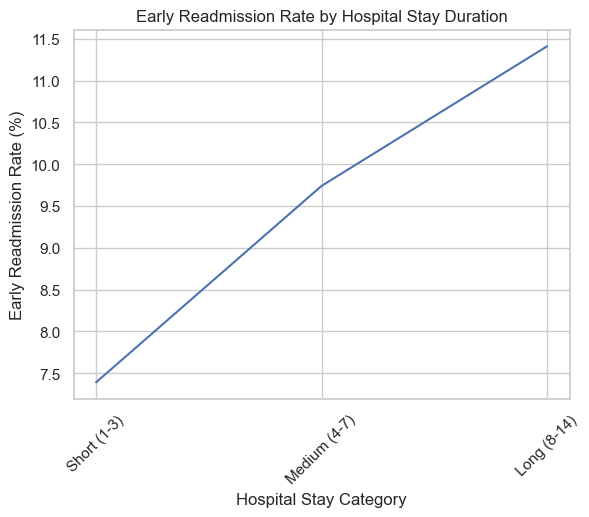

In [20]:
# Ensure logical order of stay categories
category_order = ['Short (1-3)', 'Medium (4-7)', 'Long (8-14)']

stay_analysis['stay_category'] = pd.Categorical(
    stay_analysis['stay_category'],
    categories=category_order,
    ordered=True
)

stay_analysis_sorted = stay_analysis.sort_values('stay_category')

# Create line chart
plt.figure()
plt.plot(
    stay_analysis_sorted['stay_category'],
    stay_analysis_sorted['early_readmission_rate_percent']
)

plt.xlabel('Hospital Stay Category')
plt.ylabel('Early Readmission Rate (%)')
plt.title('Early Readmission Rate by Hospital Stay Duration')

plt.xticks(rotation=45)
plt.show()

### Factor 2: Number of diagnoses
- Patients are grouped by `number_diagnoses`.
- For each group:
    - Total patients and early readmissions are calculated.
    - Early readmission rate (%) is computed using `.assign()`.
- Results are sorted to show which diagnosis counts are associated with the highest readmission rates.

In [21]:
# Aggregate readmissions by number of diagnoses
diagnosis_analysis = (
    df.groupby('number_diagnoses')
      .agg(
          total_patients=('encounter_id', 'count'),       # Count of patients
          early_readmissions=('early_readmission', 'sum') # Sum of early readmissions
      )
      .assign(
          early_readmission_rate_percent=lambda x:
          (x['early_readmissions'] / x['total_patients'] * 100).round(2) # % readmission
      )
      .sort_values('early_readmission_rate_percent', ascending=False) # Sort high → low
      .reset_index()
)

# Display the result
diagnosis_analysis

,number_diagnoses,total_patients,early_readmissions,early_readmission_rate_percent
0,14,5,1,20.00
1,11,6,1,16.67
2,12,7,1,14.29
3,15,7,1,14.29
4,10,9,1,11.11
5,13,10,1,10.00
6,9,31739,3088,9.73
7,16,31,3,9.68
8,8,7560,724,9.58
9,6,7691,653,8.49


### Visualization

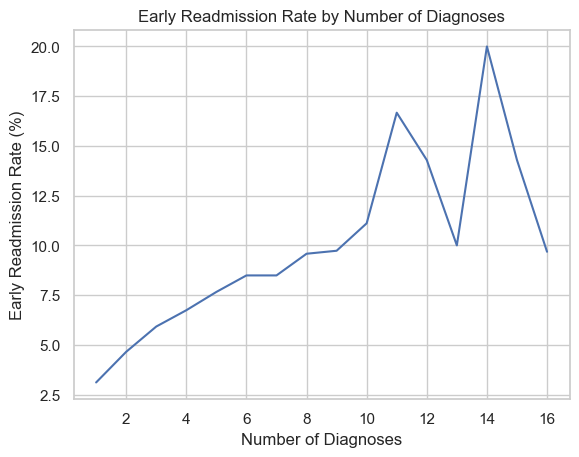

In [22]:
# Sort by number of diagnoses for proper line progression
diagnosis_analysis_sorted = diagnosis_analysis.sort_values('number_diagnoses')

plt.figure()
plt.plot(
    diagnosis_analysis_sorted['number_diagnoses'],
    diagnosis_analysis_sorted['early_readmission_rate_percent']
)

plt.xlabel('Number of Diagnoses')
plt.ylabel('Early Readmission Rate (%)')
plt.title('Early Readmission Rate by Number of Diagnoses')

plt.show()

### Factor 3: Number of Procedures
- Patients are grouped by `num_procedures`.
- For each group:
    - Total patients and early readmissions are calculated.
    - Early readmission rate (%) is computed.
- Sorting allows assessment of whether more procedures increase the likelihood of readmission.

In [23]:
# Aggregate readmissions by number of procedures
procedures_analysis = (
    df.groupby('num_procedures')
      .agg(
          total_patients=('encounter_id', 'count'),       # Count of patients per procedure count
          early_readmissions=('early_readmission', 'sum') # Sum of early readmissions
      )
      .assign(
          early_readmission_rate_percent=lambda x:
          (x['early_readmissions'] / x['total_patients'] * 100).round(2) # % readmission
      )
      .sort_values('early_readmission_rate_percent', ascending=False) # Sort high → low
      .reset_index()
)

# Display the result
procedures_analysis

,num_procedures,total_patients,early_readmissions,early_readmission_rate_percent
0,1,14302,1345,9.40
1,4,3056,285,9.33
2,3,7183,647,9.01
3,2,9149,792,8.66
4,0,31430,2700,8.59
5,5,2439,201,8.24
6,6,3956,323,8.16


### Factor 4: Number of Medications
- Patients are grouped by `num_medications`.
- Aggregations include total patients, early readmissions, and readmission rate (%).
- Sorting identifies whether higher medication counts are associated with increased readmission risk.

In [24]:
# Aggregate readmissions by number of medications
medications_analysis = (
    df.groupby('num_medications')
      .agg(
          total_patients=('encounter_id', 'count'),       # Count of patients per medication count
          early_readmissions=('early_readmission', 'sum') # Sum of early readmissions
      )
      .assign(
          early_readmission_rate_percent=lambda x:
          (x['early_readmissions'] / x['total_patients'] * 100).round(2) # % readmission
      )
      .sort_values('early_readmission_rate_percent', ascending=False) # Sort high → low
      .reset_index()
)

# Display top 15 categories with highest readmission rates
medications_analysis.head(15)

,num_medications,total_patients,early_readmissions,early_readmission_rate_percent
0,81,1,1,100.00
1,72,2,2,100.00
2,70,2,1,50.00
3,67,5,2,40.00
4,68,5,1,20.00
5,46,74,13,17.57
6,55,20,3,15.00
7,59,14,2,14.29
8,42,102,14,13.73
9,38,162,21,12.96


## Hospital Readmission – Insights & Recommendations

| Factor | Insight | Recommendation |
|--------|---------|----------------|
| **Length of Hospital Stay** | Longer stays are associated with higher early readmission rates. Reflects severe conditions or complications. | Monitor long-stay patients closely post-discharge; implement enhanced discharge planning and follow-up care. |
| **Number of Diagnoses** | Patients with multiple diagnoses show higher readmission rates, indicating complex medical conditions increase risk. | Identify high-risk patients with comorbidities; coordinate multidisciplinary care and personalized treatment plans. |
| **Number of Procedures** | Patients with many procedures do not necessarily have higher readmission rates. | Focus on quality of post-procedure care; ensure adequate monitoring and follow-up for patients undergoing multiple procedures. |
| **Number of Medications** | Patients on higher numbers of medications often have higher readmission rates; reflects complex treatment plans. | Provide medication reconciliation and counseling at discharge; simplify treatment plans where possible to reduce errors and improve adherence. |

## Key Question 3: How Demographics Affect Recovery Outcomes

This analysis examines how patient demographics (**gender, age, and race**) influence recovery outcomes.  

### Gender
- Patients are grouped by `gender`.  
- Aggregations include total patients, successful recoveries, and early readmissions.  
- The success rate (%) is calculated for each gender and sorted to identify which gender group has the best recovery outcomes.  


In [25]:
# Aggregate recovery and readmission data by gender
recovery_analysis = df.groupby(['gender']).agg(
    total_patients=('encounter_id','count'),           # Total patients per gender
    successful_recoveries=('successful_recovery','sum'), # Number of successful recoveries
    early_readmissions=('early_readmission','sum')     # Number of early readmissions
).reset_index()

# Calculate recovery success rate (%)
recovery_analysis['success_rate_percent'] = (
    recovery_analysis['successful_recoveries'] / recovery_analysis['total_patients'] * 100
).round(2)

# Sort by success rate descending to identify highest recovery rates
recovery_analysis = recovery_analysis.sort_values('success_rate_percent', ascending=False)

# Display the result
recovery_analysis

,gender,total_patients,successful_recoveries,early_readmissions,success_rate_percent
1,Male,33490,30567,2923,91.27
0,Female,38025,34655,3370,91.14


### Age
- Patients are grouped by `age`.  
- Total patients, successful recoveries, and early readmissions are calculated per age group.  
- The success rate (%) is computed, providing insight into which age ranges experience better recovery outcomes.  


In [26]:
# Aggregate recovery and readmission data by age
recovery_analysis = df.groupby(['age']).agg(
    total_patients=('encounter_id','count'),           # Total patients per age
    successful_recoveries=('successful_recovery','sum'), # Number of successful recoveries
    early_readmissions=('early_readmission','sum')     # Number of early readmissions
).reset_index()

# Calculate recovery success rate (%)
recovery_analysis['success_rate_percent'] = (
    recovery_analysis['successful_recoveries'] / recovery_analysis['total_patients'] * 100
).round(2)

# Sort by success rate descending to identify age groups with highest recovery
recovery_analysis = recovery_analysis.sort_values('success_rate_percent', ascending=False)

# Display the result
recovery_analysis

,age,total_patients,successful_recoveries,early_readmissions,success_rate_percent
0,[0-10),154,151,3,98.05
1,[10-20),535,509,26,95.14
3,[30-40),2699,2511,188,93.03
5,[50-60),12466,11587,879,92.95
2,[20-30),1127,1044,83,92.64
4,[40-50),6878,6371,507,92.63
9,[90-100),1900,1732,168,91.16
6,[60-70),15959,14545,1414,91.14
7,[70-80),18208,16384,1824,89.98
8,[80-90),11589,10388,1201,89.64


### Race
- Patients are grouped by `race`.  
- Aggregations and success rate calculations are performed similarly.  
- Sorting identifies which racial groups have higher or lower recovery success rates.  

In [27]:
# Aggregate recovery and readmission data by race
recovery_analysis = df.groupby(['race']).agg(
    total_patients=('encounter_id','count'),           # Total patients per race
    successful_recoveries=('successful_recovery','sum'), # Number of successful recoveries
    early_readmissions=('early_readmission','sum')     # Number of early readmissions
).reset_index()

# Calculate recovery success rate (%)
recovery_analysis['success_rate_percent'] = (
    recovery_analysis['successful_recoveries'] / recovery_analysis['total_patients'] * 100
).round(2)

# Sort by success rate descending to identify races with highest recovery
recovery_analysis = recovery_analysis.sort_values('success_rate_percent', ascending=False)

# Display the result
recovery_analysis

,race,total_patients,successful_recoveries,early_readmissions,success_rate_percent
4,Other,1177,1097,80,93.20
3,Hispanic,1517,1395,122,91.96
1,Asian,497,456,41,91.75
0,AfricanAmerican,12887,11794,1093,91.52
2,Caucasian,53491,48675,4816,91.00


### Visualization

#### Recovery Success Heatmap by Age and Gender

**Purpose:**  
Visualize recovery success rates across age and gender to quickly identify which patient subgroups have higher or lower likelihood of successful recovery.

**Visualization Details:**  
- **Rows:** Age groups  
- **Columns:** Gender  
- **Cell Values:** Success rate (%)  
- **Color Gradient:** Darker shades indicate higher recovery success.  
- **Annotations:** Each cell shows the exact success rate.  

**Key Point:**  
This heatmap allows rapid comparison of recovery outcomes across demographic subgroups, highlighting patterns and potential areas for focused interventions.  


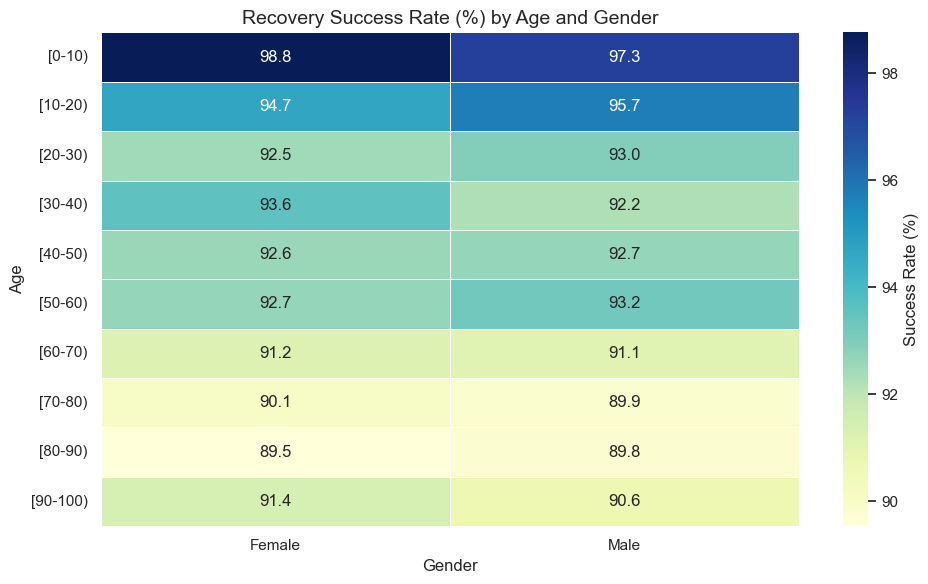

In [28]:
# Recovery outcomes aggregated by age and gender
recovery_analysis = df.groupby(['age', 'gender']).agg(
    total_patients=('encounter_id', 'count'),
    successful_recoveries=('successful_recovery', 'sum')
).reset_index()

# Calculate success rate %
recovery_analysis['success_rate_percent'] = (
    recovery_analysis['successful_recoveries'] / recovery_analysis['total_patients'] * 100
).round(2)

# Pivot for heatmap
pivot_table = recovery_analysis.pivot_table(
    index='age',
    columns='gender',
    values='success_rate_percent',
    aggfunc='mean'  
)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Success Rate (%)'}
)
plt.title("Recovery Success Rate (%) by Age and Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

## Recovery Outcomes – Demographics Insights & Recommendations

| Demographic Factor | Insight | Recommendation |
|-------------------|--------|----------------|
| **Gender** | Recovery success rates differ slightly between genders; one gender may have a marginally higher likelihood of successful recovery and lower early readmission. | Consider **gender-specific care strategies**; monitor recovery trends and adjust treatment or follow-up to optimize outcomes for each gender. |
| **Age** | Younger patients tend to have higher recovery success rates; older patients show lower success rates and higher early readmission, likely due to comorbidities or slower healing. | Implement **age-specific care plans**: provide additional monitoring and support for older patients; tailor interventions to accelerate recovery. |
| **Race** | Recovery outcomes vary across racial groups; some races demonstrate higher success rates while others show lower outcomes, indicating demographic influence on recovery patterns. | Incorporate **race-informed care approaches**; ensure equitable access to resources, monitor outcomes by race, and adjust treatment protocols as needed. |

# Limitations & Interpretation Notes

While this analysis provides valuable insights into treatment effectiveness, readmission patterns, and recovery outcomes, the results should be interpreted with caution.

### 1. Correlation vs Causation
This analysis is observational and identifies statistical associations between variables.  
It does not establish causal relationships. 

For example, while longer hospital stays may be associated with higher readmission rates, this does not mean longer stays directly cause readmissions. Other underlying factors (e.g., illness severity, comorbidities, or hospital practices) may influence outcomes.

### 2. Historical Dataset
The dataset covers hospital encounters from 1999–2008.  
Clinical practices, treatment protocols, and healthcare systems may have evolved since then. Therefore, findings may not fully reflect current healthcare environments.

### 3. Sample Size Considerations
Some subgroup aggregations are based on relatively small patient counts.  

Small sample sizes may:
- Produce unstable percentages
- Exaggerate trends
- Reduce statistical reliability

Insights derived from smaller groups should be interpreted cautiously and validated against larger population trends.

### 4. Data Quality & Simplified Categories
Certain variables contain simplified categorical values (e.g., Up, Down, Steady, No) that may not fully capture clinical complexity. Additionally, missing values and limited contextual variables (such as socioeconomic factors or hospital-level characteristics) may affect the depth of interpretation.

### 5. Generalizability
The dataset represents patients from 130 U.S. hospitals.  
Findings may not be directly generalizable to other countries, healthcare systems, or patient populations without further validation.

---

Overall, the results should be viewed as data-driven insights that highlight patterns and associations, rather than definitive clinical conclusions.